In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv('online_gaming_behavior_dataset.csv')
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

,0
PlayerID,0
Age,0
Gender,0
Location,0
GameGenre,0
PlayTimeHours,0
InGamePurchases,0
GameDifficulty,0
SessionsPerWeek,0
AvgSessionDurationMinutes,0


In [5]:
df = df.dropna()

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [7]:
# Define target column
target_column = 'EngagementLevel'

# Features (X) and Target (y)
X = df.drop(['EngagementLevel', 'PlayerID'], axis=1)
y = df['EngagementLevel']

In [8]:
y.value_counts()

,count
EngagementLevel,
2,19374
0,10336
1,10324


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# Check mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for class balance
)

In [12]:
import numpy as np
print(np.bincount(y))

[10336 10324 19374]


In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

After SMOTE: [15499 15499 15499]


In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7910578244036468

Confusion Matrix:
 [[1857   94  116]
 [  78 1665  322]
 [ 407  656 2812]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.90      0.84      2067
           1       0.69      0.81      0.74      2065
           2       0.87      0.73      0.79      3875

    accuracy                           0.79      8007
   macro avg       0.78      0.81      0.79      8007
weighted avg       0.80      0.79      0.79      8007



In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [18]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Accuracy: 0.7910578244036468


In [19]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=5)  # choose top 5 features
X_new = selector.fit_transform(abs(X), y)  # use abs because chi2 needs positive

print("Selected Features Index:", selector.get_support(indices=True))

Selected Features Index: [ 3  5  7  8 10]


In [22]:
import pandas as pd

feature_names = df.drop(['EngagementLevel', 'PlayerID'], axis=1).columns

coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                      Feature  Importance
7             SessionsPerWeek    2.026513
8   AvgSessionDurationMinutes    1.760237
10       AchievementsUnlocked    0.157975
9                 PlayerLevel    0.152213
5             InGamePurchases    0.034080
4               PlayTimeHours    0.017530
6              GameDifficulty    0.000630
2                    Location   -0.003006
1                      Gender   -0.005229
0                         Age   -0.009212
3                   GameGenre   -0.011093


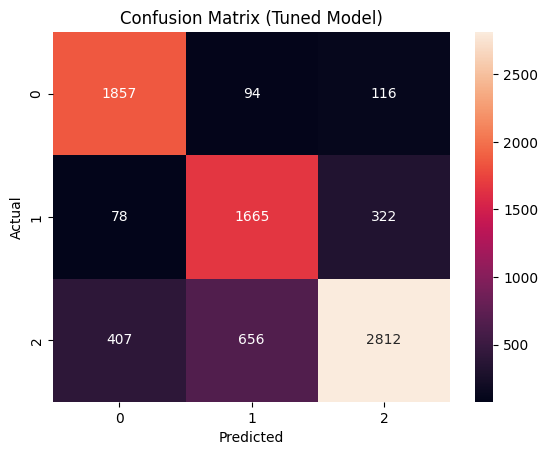

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Tuned Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
results = {
    "Logistic Regression (Base)": accuracy_score(y_test, y_pred),
    "Logistic Regression (Tuned)": accuracy_score(y_test, y_pred_best)
}

print(results)

{'Logistic Regression (Base)': 0.7910578244036468, 'Logistic Regression (Tuned)': 0.7910578244036468}


In [25]:
##IMPROVEMENTS
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=6)

X_selected = selector.fit_transform(X, y)

# Split again (IMPORTANT!)
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

model_fs = LogisticRegression(max_iter=1000)
model_fs.fit(X_train_fs, y_train_fs)

y_pred_fs = model_fs.predict(X_test_fs)

from sklearn.metrics import accuracy_score
print("Feature Selection Accuracy:", accuracy_score(y_test_fs, y_pred_fs))

Feature Selection Accuracy: 0.818658673660547


In [26]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Split again
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y, test_size=0.2, random_state=42, stratify=y
)

model_poly = LogisticRegression(max_iter=2000)
model_poly.fit(X_train_poly, y_train_poly)

y_pred_poly = model_poly.predict(X_test_poly)

print("Polynomial Accuracy:", accuracy_score(y_test_poly, y_pred_poly))

Polynomial Accuracy: 0.8719870113650556


In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))

Tuned Accuracy: 0.7910578244036468


In [30]:
results = {
    "Base Model": accuracy_score(y_test, y_pred),
    "Feature Selection": accuracy_score(y_test_fs, y_pred_fs),
    "Polynomial": accuracy_score(y_test_poly, y_pred_poly),
    "Tuned Model": accuracy_score(y_test, y_pred_tuned)
}

print(results)

{'Base Model': 0.7910578244036468, 'Feature Selection': 0.818658673660547, 'Polynomial': 0.8719870113650556, 'Tuned Model': 0.7910578244036468}


In [32]:
# Sample prediction table for Logistic Regression (best model)

import pandas as pd
import numpy as np

sample_n = 12

# Get sample indices from the X_test_poly (which has the correct number of features)
# Ensure that the sampling preserves the relationship between features and target.
np.random.seed(42) # for reproducibility of sampling
sample_indices = np.random.choice(len(X_test_poly), sample_n, replace=False)

sample_X_poly = X_test_poly[sample_indices]
sample_y_poly_actual = y_test_poly[sample_indices]

# Predict using best model (model_poly)
sample_pred = model_poly.predict(sample_X_poly)

result_df = pd.DataFrame({
    "Actual": sample_y_poly_actual,
    "Predicted": sample_pred
})

result_df["Correct"] = result_df["Actual"] == result_df["Predicted"]

print(result_df)
print("\nSample Accuracy:", round(result_df["Correct"].mean() * 100, 2), "%")

    Actual  Predicted  Correct
0        2          2     True
1        0          0     True
2        2          2     True
3        0          0     True
4        1          1     True
5        0          0     True
6        2          2     True
7        2          2     True
8        2          2     True
9        0          0     True
10       0          0     True
11       2          2     True

Sample Accuracy: 100.0 %


In [34]:
result_df.style.apply(
    lambda x: ['background-color: lightgreen' if v else 'salmon' for v in x],
    subset=['Correct']
)

,Actual,Predicted,Correct
0,2,2,True
1,0,0,True
2,2,2,True
3,0,0,True
4,1,1,True
5,0,0,True
6,2,2,True
7,2,2,True
8,2,2,True
9,0,0,True


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_poly))

              precision    recall  f1-score   support

           0       0.92      0.83      0.87      2067
           1       0.88      0.79      0.84      2065
           2       0.85      0.94      0.89      3875

    accuracy                           0.87      8007
   macro avg       0.88      0.85      0.87      8007
weighted avg       0.87      0.87      0.87      8007



In [37]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_poly, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean CV Accuracy:", scores.mean())

Cross-validation scores: [0.82065693 0.83164731 0.82028225 0.82752591 0.82063452]
Mean CV Accuracy: 0.8241493851510955


In [38]:
from sklearn.metrics import roc_auc_score

y_prob = model_poly.predict_proba(X_test_poly)

roc = roc_auc_score(y_test_poly, y_prob, multi_class='ovr')
print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.9381508685968328


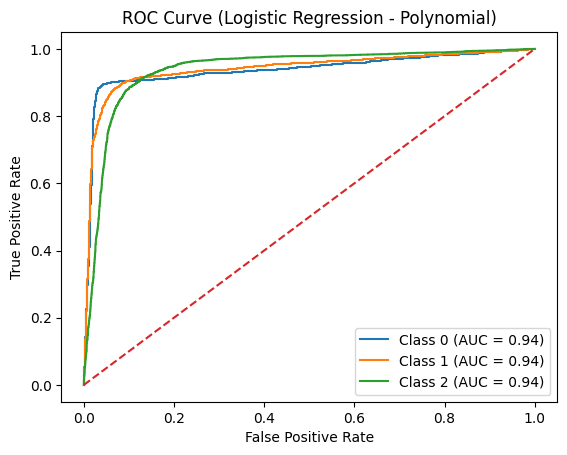

In [42]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize labels
y_test_bin = label_binarize(y_test_poly, classes=[0,1,2])

# Get probabilities
y_score = model_poly.predict_proba(X_test_poly)

plt.figure()

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression - Polynomial)")
plt.legend()
plt.show()

In [39]:
from sklearn.metrics import log_loss

print("Log Loss:", log_loss(y_test_poly, y_prob))

Log Loss: 0.468964989119657


In [40]:
model_better = LogisticRegression(
    C=0.5,              # try smaller values
    penalty='l2',
    solver='lbfgs',
    max_iter=3000
)

model_better.fit(X_train_poly, y_train_poly)

y_pred_better = model_better.predict(X_test_poly)

print("Improved Accuracy:", accuracy_score(y_test_poly, y_pred_better))

Improved Accuracy: 0.8714874484825778
